In [30]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt


############
# parameters
############

N_arr = np.arange(2, 10, 1)
nc = 30
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, 2*np.pi, 0.0001)

#############################
# Central-Spin Hamiltonian
#############################

def central_spin_chain(N, nb, ω, ω0, g):
   
# ======== Spin-1/2 operators ====================
    
    sp = qt.sigmap()
    sm = qt.sigmam()
    sz = qt.sigmaz()

# ======== Embed single-spin operator =================

    def embed(op, i):
        ops = [qt.qeye(2)] * N
        ops[i] = op
        return qt.tensor(ops)

# ======== Battery operators ============

    Bp = [embed(sp, i) for i in range(N)]
    Bm = [embed(sm, i) for i in range(N)]
    Bz = [0.5 * embed(sz, i) for i in range(N)]

# ======== Charger collective operators ============

    JpC = qt.jmat(nc / 2, '+')
    JmC = qt.jmat(nc / 2, '-')
    JzC = qt.jmat(nc / 2, 'z')
    
# ======== Identities =================

    IC = qt.qeye(nc+1)
    IB = qt.tensor([qt.qeye(2) for _ in range(N)])
    I_full = qt.tensor(IB, IC)

# ======== Embedded operators into full space =============

# ====== Battery operators ==========

    Bp_full = [qt.tensor(op, IC) for op in Bp]
    Bm_full = [qt.tensor(op, IC) for op in Bm]
    Bz_full = [qt.tensor(op, IC) for op in Bz]

# ===== Charger operators ===========

    JpC_full = qt.tensor(IB, JpC)
    JmC_full = qt.tensor(IB, JmC)
    JzC_full = qt.tensor(IB, JzC)

# ======== Battery Hamiltonian =============

    HB = ω0 * (sum(Bz_full) + 0.5 * N * I_full)
    
# ======== Charger Hamiltonian =============

    HC = ω * (JzC_full + 0.5 * nc * I_full)

# ======== Interaction Hamiltonian ===========

    Hint = 0

    for i in range(N):
        
        Hint += g * (Bp_full[i] * JmC_full + Bm_full[i] * JpC_full)

# ======== Total Hamiltonian =====================

    H = HB + HC + Hint

# ======= Battery-only Hamiltonian ==============


    HB_local = ω * (sum([0.5 * embed(sz, i) for i in range(N)]) + 0.5 * N * IB)

    return H, HB, HB_local


###################
# Initial state
###################

def initial_state(N, nc):

# ========= Battery state: all spins DOWN (ground) ================
    
    psiB = qt.tensor([qt.basis(2,1) for _ in range(N)])

# ========= Charger state: all spins UP (excited) ==================
    
    psiC = qt.basis(nc+1, 0)

    return qt.tensor(psiB, psiC)


##############
# Pnm matrix
##############

def pnm_matrix(rho, H):

    r_val, r_vec = rho.eigenstates()
    idx = np.argsort(r_val)[::-1]
    r_val = r_val[idx]
    r_vec = [r_vec[i] for i in idx]

    e_val, e_vec = H.eigenstates()

    pnm = np.zeros((len(e_val), len(e_val)))
    for n in range(len(e_val)):
        for m in range(len(e_val)):
            pnm[n, m] = r_val[m]*abs(e_vec[n].overlap(r_vec[m]))**2

    return pnm, r_val, e_val


############################
# ergotropy using pnm matrix
############################

def ergotropy_pnm(pnm, r_val, e_val):
    deltaE = e_val[:,None] - e_val[None,:]
    return np.sum(pnm * deltaE)


############################
# variance using pnm matrix
############################

def variance_pnm(pnm, r_val, e_val):
    deltaE2 = (e_val[:,None] - e_val[None,:])**2
    mean2 = np.sum(pnm * deltaE2)
    mean = ergotropy_pnm(pnm, r_val, e_val)
    return mean2 - mean**2

N= 2, τ=0.2023, E_B=1.611734
N= 3, τ=0.1896, E_B=2.377366
N= 4, τ=0.1807, E_B=3.153032
N= 5, τ=0.1738, E_B=3.937608
N= 6, τ=0.1683, E_B=4.733990
N= 7, τ=0.1636, E_B=5.536385
N= 8, τ=0.1597, E_B=6.351851
N= 9, τ=0.1563, E_B=7.175572


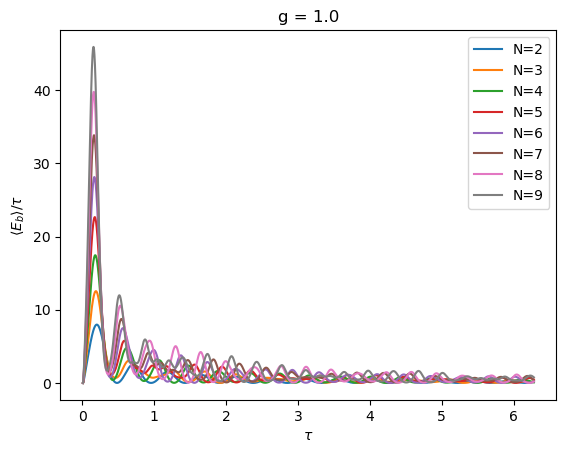

In [31]:
##############################################
# Plot Battery energy <Eb> as function of time 
# and pick time τ for which <Eb> is maximum
##############################################
τ_list = []

for N in N_arr:

    H, HB, HB_local = central_spin_chain(N, nc, ω, ω0, g)

    # Initial state
    ψ0 = initial_state(N, nc)

    opts = qt.Options(atol=1e-16, rtol=1e-14)        ## ODE solver options
    # Time evolution
    result = qt.sesolve(H, ψ0, tlist, e_ops=HB, options=opts)

    # Battery energy vs time
    Eb_list = np.array(result.expect[0])

    # Maximize charging power (Eb / t)
    power = Eb_list / tlist
    
    idx = np.argmax(power)
    
    τ = tlist[idx]
    
    τ_list.append(τ)

    print(f"N={N:2d}, τ={tlist[idx]:.4f}, E_B={Eb_list[idx]:.6f}")
    
    ##################################
    # Plot of battery energy with time
    ##################################
    
    plt.plot(tlist, power, label=f"N={N}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle E_b \rangle / \tau$")
plt.legend()
plt.title(f"g = {g}")
plt.show()

N= 2, τ=0.2023, Eb=1.683793, Ergotropy=1.492396, erg/Eb=0.886329497851 Variance=1.1319735565e+00
N= 3, τ=0.1896, Eb=2.487427, Ergotropy=2.246315, erg/Eb=0.903068027007 Variance=1.8909326239e+00
N= 4, τ=0.1807, Eb=3.302236, Ergotropy=3.024735, erg/Eb=0.915965760683 Variance=2.7015793565e+00
N= 5, τ=0.1738, Eb=4.127136, Ergotropy=3.820477, erg/Eb=0.925696687933 Variance=3.5667086541e+00
N= 6, τ=0.1683, Eb=4.963834, Ergotropy=4.633651, erg/Eb=0.933482267412 Variance=4.4769812804e+00
N= 7, τ=0.1636, Eb=5.808554, Ergotropy=5.458375, erg/Eb=0.939713290934 Variance=5.4406374200e+00
N= 8, τ=0.1597, Eb=6.665619, Ergotropy=6.299227, erg/Eb=0.945032552160 Variance=6.4347987664e+00
N= 9, τ=0.1563, Eb=7.532193, Ergotropy=7.152285, erg/Eb=0.949562071539 Variance=7.4648805802e+00


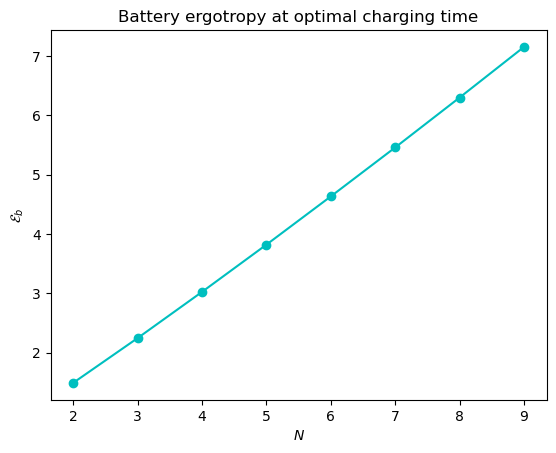

In [32]:
Eb_list = []
erg_list = []
var_list = []
ratio_list = []

for i, N in enumerate(N_arr):

    τ = τ_list[i]

    # Rebuild Hamiltonian
    H, HB, HB_local = central_spin_chain(N, nc, ω, ω0, g)

    # Initial state
    ψ0 = initial_state(N, nc)

    # Evolve until τ
    result = qt.sesolve(H, ψ0, [0, τ], options=opts)

    # Full density matrix at τ
    ρ_full = result.states[-1]

    # Partial trace over cavity (subsystem 0)
    ρb = ρ_full.ptrace(list(range(N)))

    Eb = qt.expect(HB_local, ρb)
    
    pnm, r_val, e_val = pnm_matrix(ρb, HB_local)

    # Ergotropy via pnm matrix
    erg = ergotropy_pnm(pnm, r_val, e_val)

    # Variance via pnm matrix
    var = variance_pnm(pnm, r_val, e_val)

    ratio = erg/Eb

    print(f"N={N:2d}, τ={τ:.4f}, Eb={Eb:.6f}, Ergotropy={erg:.6f}, erg/Eb={ratio:.12f} Variance={var:.10e}")

    Eb_list.append(Eb)
    erg_list.append(erg)
    var_list.append(var)
    ratio_list.append(ratio)

Eb_arr = np.array(Eb_list)
erg_arr = np.array(erg_list)
var_arr = np.array(var_list)

rel_fluct = np.sqrt(var_arr) / erg_arr

rel_fluc = np.sqrt(var_arr) / Eb_arr

###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.figure()
plt.plot(N_arr, erg_list, 'o-', color='c')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
#plt.savefig("WS1.png")
plt.show()

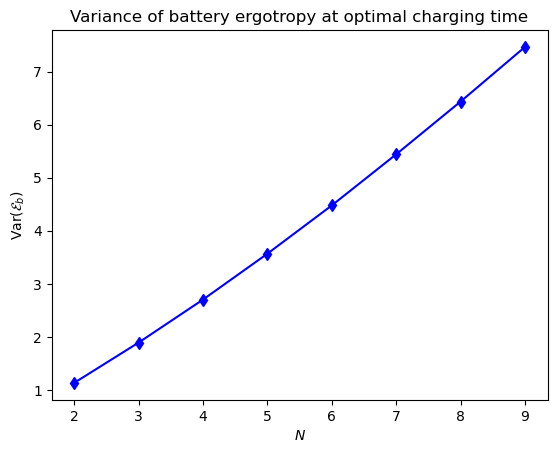

In [33]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, var_list, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
#plt.savefig("WS2.png")
plt.show()

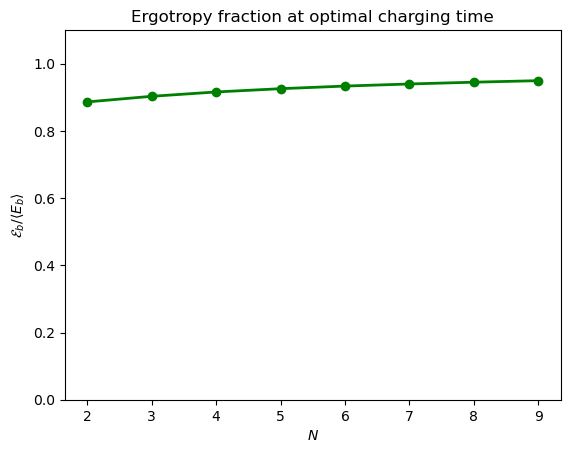

In [34]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
#############################################################


plt.figure()
plt.plot(N_arr, ratio_list, 'o-', color='g', linewidth=2)
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
#plt.savefig("WS3.png")
plt.show()

N= 2, τ=0.2023, Relative Fluctuation =0.712909087622, Relative Fluctuation with Eb =0.631872353645
N= 3, τ=0.1896, Relative Fluctuation =0.612163304111, Relative Fluctuation with Eb =0.552825107249
N= 4, τ=0.1807, Relative Fluctuation =0.543402314140, Relative Fluctuation with Eb =0.497737914028
N= 5, τ=0.1738, Relative Fluctuation =0.494329221040, Relative Fluctuation with Eb =0.457598922665
N= 6, τ=0.1683, Relative Fluctuation =0.456635126118, Relative Fluctuation with Eb =0.426260792908
N= 7, τ=0.1636, Relative Fluctuation =0.427328133618, Relative Fluctuation with Eb =0.401565926751
N= 8, τ=0.1597, Relative Fluctuation =0.402698685779, Relative Fluctuation with Eb =0.380563366773
N= 9, τ=0.1563, Relative Fluctuation =0.382002867805, Relative Fluctuation with Eb =0.362735434486


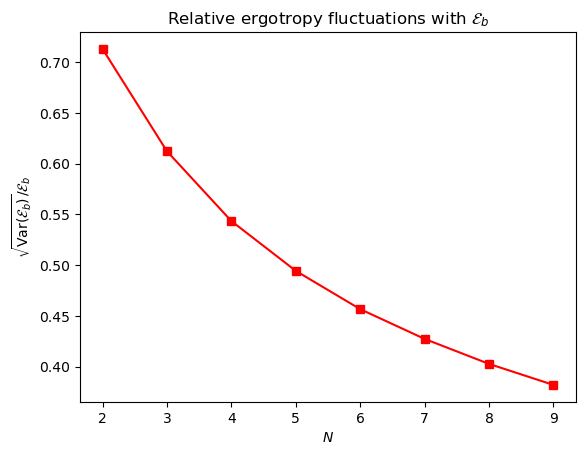

In [35]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.4f}, Relative Fluctuation ={rel_fluct[idx]:.12f}, Relative Fluctuation with Eb ={rel_fluc[idx]:.12f}")

#######################################################################
# Plot fluctuations w.r.t ergotropy as a function of g for different N 
#######################################################################

plt.figure()
plt.plot(N_arr, rel_fluct, 's-', color='r')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations with $\mathcal{E}_b$")
#plt.savefig("WS4.png")
plt.show()

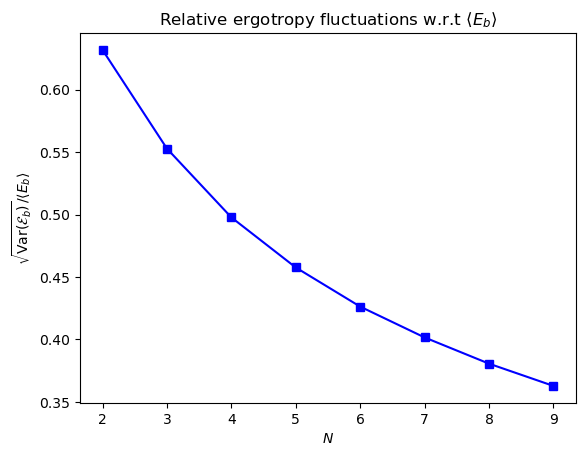

In [36]:
############################################################################
# Plot fluctuations w.r.t battery energy as a function of g for different N 
############################################################################

plt.figure()
plt.plot(N_arr, rel_fluc, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
#plt.savefig("WS5.png")
plt.show()